In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harisri2005/plant-disease-processed")

print("Path to dataset files:", path)

100%|██████████| 4.33G/4.33G [00:44<00:00, 105MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/harisri2005/plant-disease-processed/versions/1


In [ ]:
import os

# List the contents of the downloaded directory
print(os.listdir(path))

['metadata', 'outputs', 'master_images']


In [ ]:
image_path = os.path.join(path, 'master_images', 'master_images', 'images')
print(os.listdir(image_path))

['img_00048924.jpg', 'img_00053564.jpg', 'img_00000535.jpg', 'img_00008510.jpg', 'img_00028264.JPG', 'img_00028328.JPG', 'img_00043707.jpg', 'img_00049702.jpg', 'img_00041048.jpg', 'img_00042016.jpg', 'img_00004823.jpg', 'img_00041746.jpg', 'img_00012671.jpg', 'img_00059319.jpg', 'img_00015894.JPG', 'img_00030551.JPG', 'img_00022698.JPG', 'img_00014987.JPG', 'img_00064162.jpg', 'img_00058310.jpg', 'img_00010851.jpg', 'img_00002729.jpg', 'img_00004259.jpg', 'img_00063690.jpg', 'img_00008939.jpg', 'img_00059205.jpg', 'img_00026602.JPG', 'img_00063359.jpg', 'img_00025488.JPG', 'img_00057810.jpg', 'img_00000584.jpg', 'img_00000527.jpg', 'img_00021698.JPG', 'img_00026864.JPG', 'img_00047255.jpg', 'img_00015383.JPG', 'img_00020944.JPG', 'img_00033115.JPG', 'img_00058756.jpg', 'img_00034283.JPG', 'img_00058572.jpg', 'img_00065432.jpg', 'img_00062568.jpg', 'img_00044270.jpg', 'img_00039516.jpg', 'img_00019648.JPG', 'img_00003206.jpg', 'img_00051089.jpg', 'img_00054664.jpg', 'img_00006218.jpg',

In [ ]:
metadata_path = os.path.join(path, 'metadata', 'metadata')
print(os.listdir(metadata_path))

['class_map.csv', 'dedup_manifest.csv', 'dataset_manifest.csv', 'class_id_map.csv', 'source_manifest_full.csv']


In [ ]:
import pandas as pd

class_map_file = os.path.join(metadata_path, 'class_map.csv')
class_map_df = pd.read_csv(class_map_file)

print(class_map_df.head())

  source_dataset_path    source_class             canonical_class       crop
0      blackgram/BPLD   yellow mosaic   Blackgram - Yellow Mosaic  Blackgram
1      blackgram/BPLD   leaf crinckle    Blackgram - Leaf Crinkle  Blackgram
2      blackgram/BPLD     anthracnose     Blackgram - Anthracnose  Blackgram
3      blackgram/BPLD  powdery mildew  Blackgram - Powdery Mildew  Blackgram
4      blackgram/BPLD         healthy         Blackgram - Healthy  Blackgram


In [ ]:
class_counts = class_map_df['canonical_class'].value_counts()
print(class_counts.head(10))

canonical_class
Tomato - Yellow Leaf Curl Virus    3
Tomato - Healthy                   3
Tomato - Mosaic Virus              3
Tomato - Leaf Mold                 3
Tomato - Bacterial Spot            3
Bell Pepper - Bacterial Spot       3
Tomato - Septoria Leaf Spot        3
Tomato - Early Blight              3
Tomato - Late Blight               3
Bell Pepper - Healthy              3
Name: count, dtype: int64


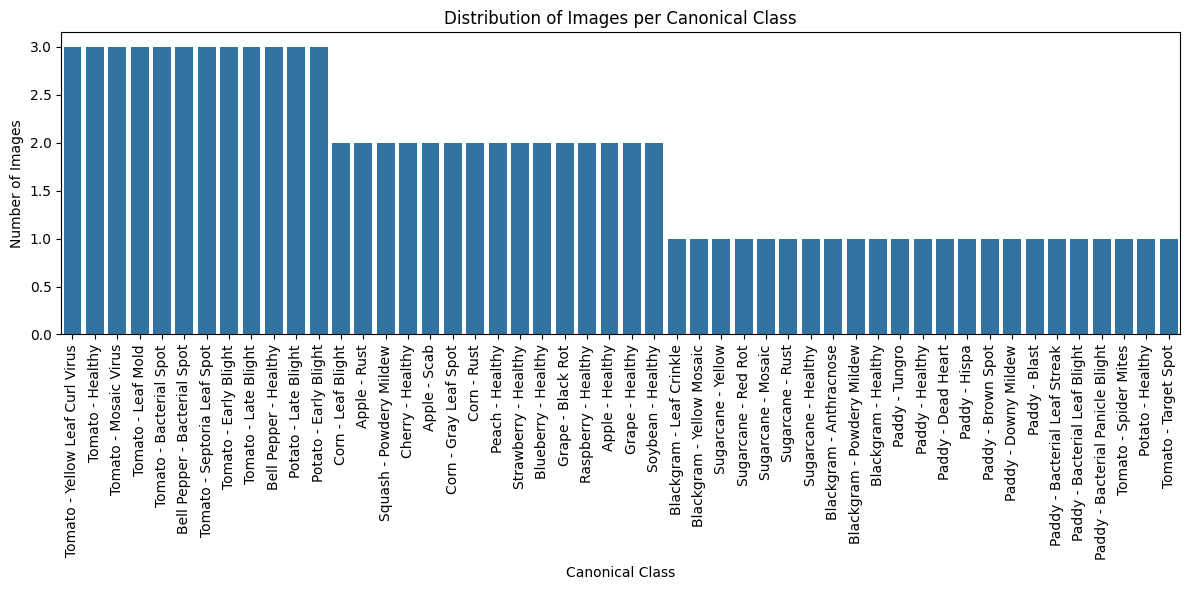

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks(rotation=90)
plt.xlabel('Canonical Class')
plt.ylabel('Number of Images')
plt.title('Distribution of Images per Canonical Class')
plt.tight_layout()
plt.show()

In [ ]:
class_id_map_file = os.path.join(metadata_path, 'class_id_map.csv')
class_id_map_df = pd.read_csv(class_id_map_file)

print(class_id_map_df.head())

            canonical_class  class_id
0           Apple - Healthy         0
1              Apple - Rust         1
2              Apple - Scab         2
3   Apple - apple black rot         3
4  Apple - apple black rot          4


In [ ]:
source_manifest_file = os.path.join(metadata_path, 'source_manifest_full.csv')
source_manifest_df = pd.read_csv(source_manifest_file)

print(source_manifest_df.head())
print(f"Total images in source_manifest_full.csv: {len(source_manifest_df)}")

                                          image_path  source_dataset  \
0  /home/hari/Professional/Projects/Plant Disease...  blackgram/BPLD   
1  /home/hari/Professional/Projects/Plant Disease...  blackgram/BPLD   
2  /home/hari/Professional/Projects/Plant Disease...  blackgram/BPLD   
3  /home/hari/Professional/Projects/Plant Disease...  blackgram/BPLD   
4  /home/hari/Professional/Projects/Plant Disease...  blackgram/BPLD   

    source_class            canonical_class       crop original_filename  
0  yellow mosaic  Blackgram - Yellow Mosaic  Blackgram          144y.jpg  
1  yellow mosaic  Blackgram - Yellow Mosaic  Blackgram          137y.jpg  
2  yellow mosaic  Blackgram - Yellow Mosaic  Blackgram          196y.jpg  
3  yellow mosaic  Blackgram - Yellow Mosaic  Blackgram          211y.jpg  
4  yellow mosaic  Blackgram - Yellow Mosaic  Blackgram           32y.jpg  
Total images in source_manifest_full.csv: 70457


Top 10 canonical classes and their counts:
canonical_class
Tomato - Yellow Leaf Curl Virus    3283
Banana - Yb sigatoka               2791
Tomato - Bacterial Spot            2234
Tomato - Late Blight               2020
Groundnut - Late leaf spot         1984
Tomato - Septoria Leaf Spot        1919
Paddy - Healthy                    1764
Paddy - Blast                      1738
Groundnut - Rust                   1723
Tomato - Spider Mites              1676
Name: count, dtype: int64

Total unique canonical classes: 332


/tmp/ipykernel_4181/2440331950.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=full_class_counts.index, y=full_class_counts.values, palette='viridis')


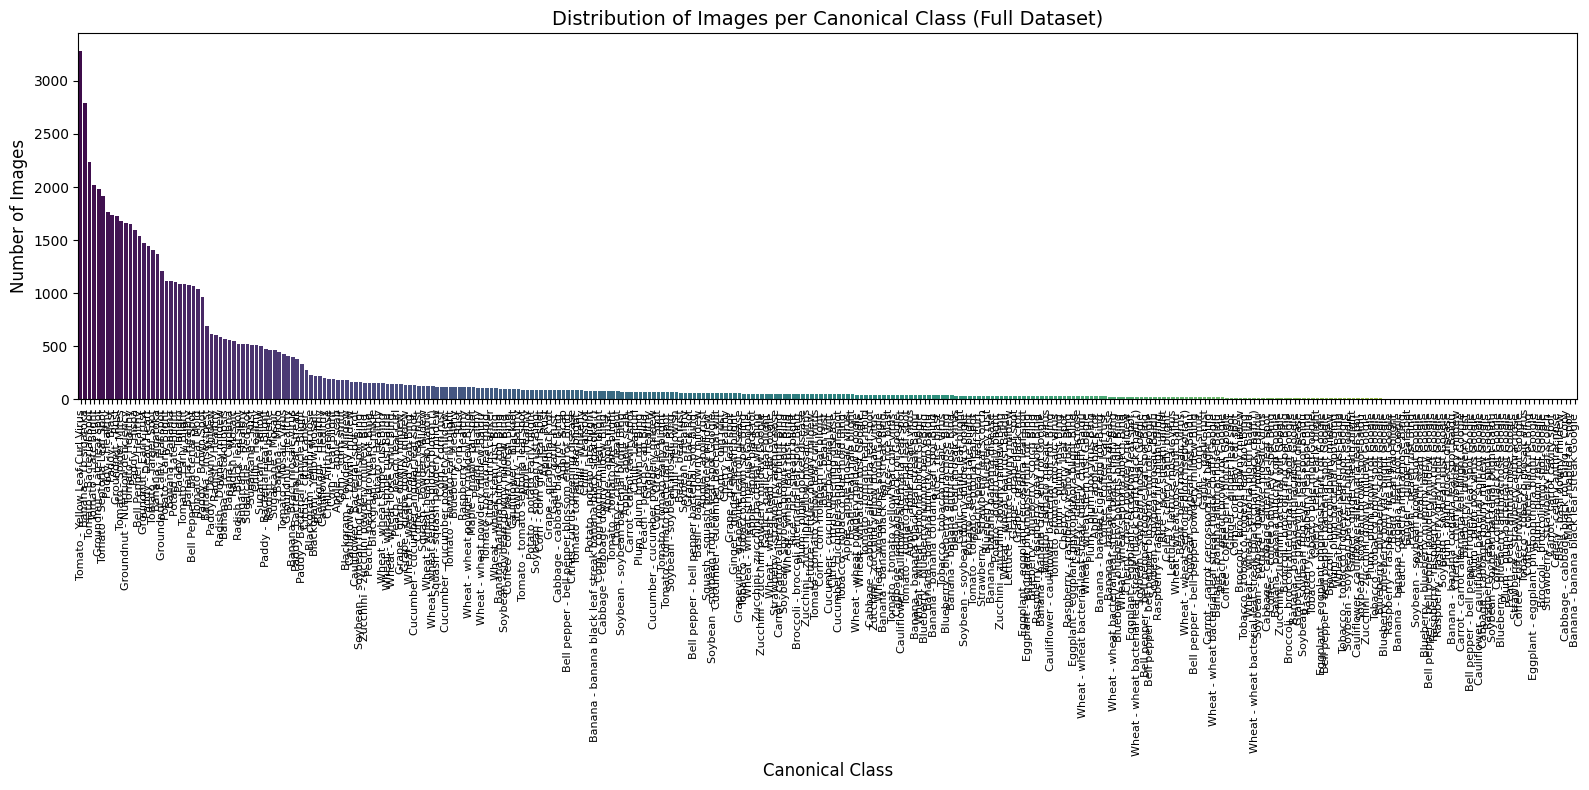

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get class counts from the full manifest
full_class_counts = source_manifest_df['canonical_class'].value_counts()

print("Top 10 canonical classes and their counts:")
print(full_class_counts.head(10))
print(f"\nTotal unique canonical classes: {len(full_class_counts)}")

# Plot the distribution of images per canonical class
plt.figure(figsize=(16, 8))
sns.barplot(x=full_class_counts.index, y=full_class_counts.values, palette='viridis')
plt.xticks(rotation=90, fontsize=8)
plt.xlabel('Canonical Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Distribution of Images per Canonical Class (Full Dataset)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adiithape1/plant-disease-detection-dataset-master-version")

print("Path to dataset files:", path)

100%|██████████| 7.69G/7.69G [01:29<00:00, 92.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/adiithape1/plant-disease-detection-dataset-master-version/versions/2


In [ ]:
import os

# List the contents of the newly downloaded directory
print(os.listdir(path))

['MasterDataset']


In [ ]:
path = os.path.join(path, 'MasterDataset')
print(os.listdir(path))

['val', 'train', 'metadata', 'test']


In [ ]:
metadata_path = os.path.join(path, 'metadata')
print(os.listdir(metadata_path))

['plant_village_manifest.csv', 'guava_manifest.csv', 'pumpkin_manifest.csv', 'rice_manifest.csv', 'sugarcane_manifest.csv', 'groundnut_manifest.csv', 'potato_manifest.csv', 'lemon_manifest.csv', 'corn_manifest.csv', 'cucumber_manifest.csv', 'wheat_manifest.csv', 'manifest_final.csv', 'bean_manifest.csv', 'cotton_manifest_all_sources.csv']


In [ ]:
import pandas as pd

manifest_final_file = os.path.join(metadata_path, 'manifest_final.csv')
manifest_final_df = pd.read_csv(manifest_final_file)

print(manifest_final_df.head())
print(f"Total images in manifest_final.csv: {len(manifest_final_df)}")

                                                path  split             class  \
0  /kaggle/working/MasterDataset/MasterDataset/tr...  train  healthy_cucumber   
1  /kaggle/working/MasterDataset/MasterDataset/tr...  train  healthy_cucumber   
2  /kaggle/working/MasterDataset/MasterDataset/tr...  train  healthy_cucumber   
3  /kaggle/working/MasterDataset/MasterDataset/tr...  train  healthy_cucumber   
4  /kaggle/working/MasterDataset/MasterDataset/tr...  train  healthy_cucumber   

                                   uuid  \
0  28bdd14a-5da6-5b51-9712-7c122cad94d5   
1  179c347a-6c2d-563d-85a1-da3641f5e156   
2  4b8c2cd3-cabb-54ab-b735-e8c6ffc27d8a   
3  45ab308c-a96b-551a-954a-4bf9de457a50   
4  36178719-9645-578b-a402-920388c85437   

                                              sha256  width  height mode  
0  1b887a208c8da09408f61345df56236d63abaf30382e66...    320     320  RGB  
1  76fda272ac602e600457e7b38cd90fc0e4b856d8d4dfb3...    320     320  RGB  
2  a717682a0570092fd17b025cc6

Top 10 classes and their counts for the new dataset:
class
sugarcane_bacterial_blight    4800
potato_early_blight           4051
potato_late_blight            3838
corn_northern_leaf_blight     3529
healthy_corn                  3486
cotton_army_worm              3483
healthy_cotton                3476
cotton_aphids                 3411
cotton_powdery_mildew         3391
cotton_target_spot            3322
Name: count, dtype: int64

Total unique classes in the new dataset: 86


/tmp/ipykernel_4181/2446030938.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=new_class_counts.index, y=new_class_counts.values, palette='viridis')


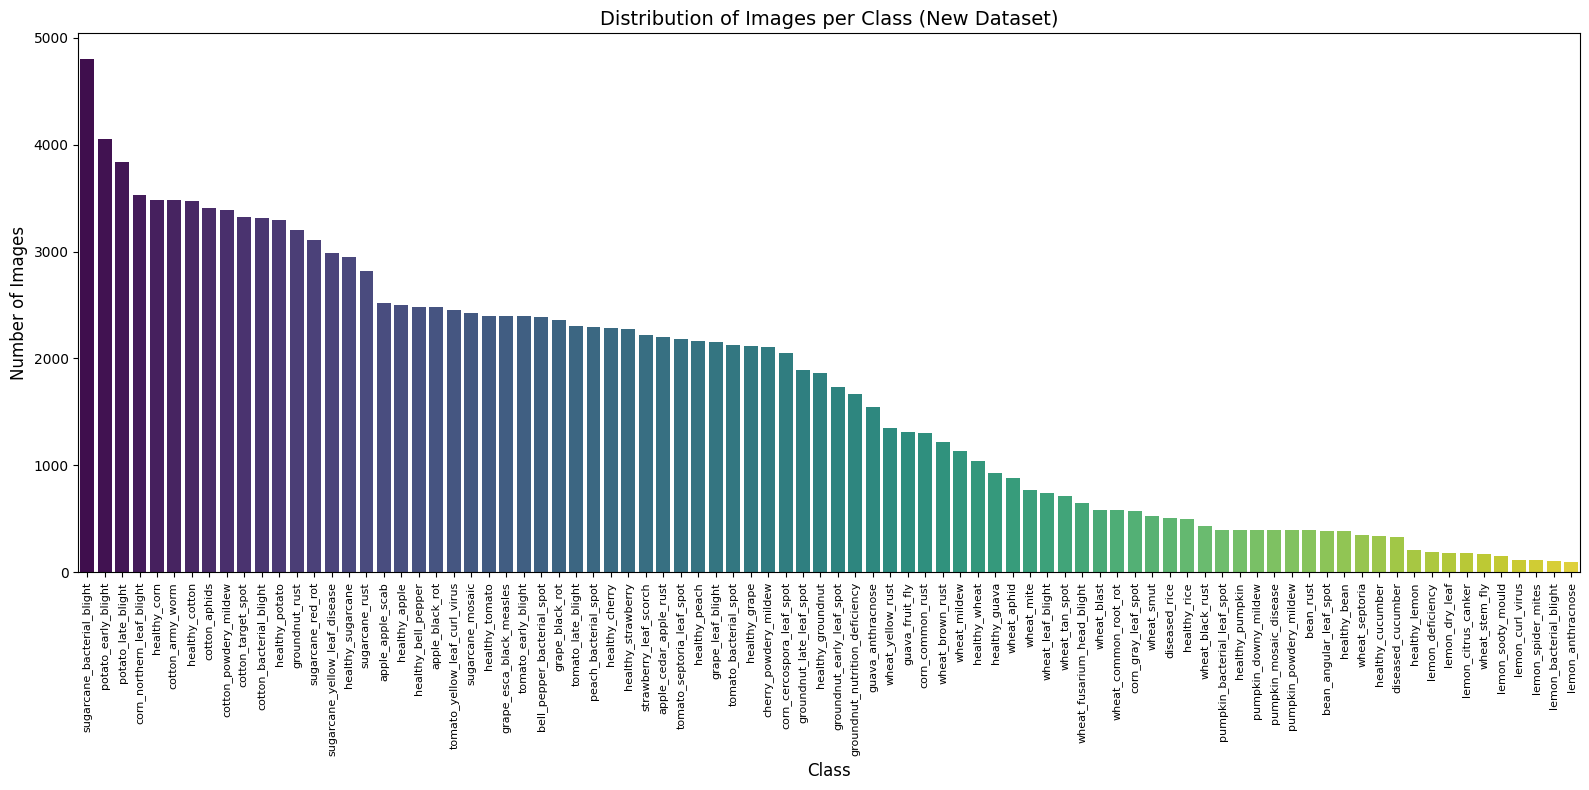

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get class counts from the new manifest
new_class_counts = manifest_final_df['class'].value_counts()

print("Top 10 classes and their counts for the new dataset:")
print(new_class_counts.head(10))
print(f"\nTotal unique classes in the new dataset: {len(new_class_counts)}")

# Plot the distribution of images per class
plt.figure(figsize=(16, 8))
sns.barplot(x=new_class_counts.index, y=new_class_counts.values, palette='viridis')
plt.xticks(rotation=90, fontsize=8)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Distribution of Images per Class (New Dataset)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np

# 1. Device Configuration (Ensure we are using the T4 GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

# --- IMPORTANT: Adjust these paths based on how you loaded the Kaggle dataset ---
# Assuming the standard Kaggle unzip structure into /kaggle/working/ or /content/
# If the dataset has 'train', 'valid', and 'test' folders inside a main directory:
DATA_DIR = path # CHANGE THIS if your unzipped folder name is different
train_dir = os.path.join(DATA_DIR, 'train') # Or whatever the train folder is named
val_dir = os.path.join(DATA_DIR, 'val')   # Or 'val'
test_dir = os.path.join(DATA_DIR, 'test')

# 2. Data Augmentation and Normalization
# Pre-trained models expect images normalized in a specific way
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Training transforms include augmentation to prevent overfitting
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Basic augmentation
    transforms.RandomRotation(10),     # Basic augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Validation/Test transforms only resize and normalize
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

print("\nSetting up DataLoaders...")
# 3. Load Datasets using ImageFolder (Assumes data is organized in folders by class)
try:
    train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
    val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transforms)
    test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

    # 4. Create DataLoaders (Batching the data for the GPU)
    batch_size = 64 # Good starting point for T4 GPU

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    class_names = train_dataset.classes
    num_classes = len(class_names)

    print(f"Successfully loaded {num_classes} classes.")
    print(f"Training images: {len(train_dataset)}")
    print(f"Validation images: {len(val_dataset)}")
    print(f"Testing images: {len(test_dataset)}")

except FileNotFoundError:
    print("\n[ERROR] Could not find the dataset directories.")
    print(f"Please check if {DATA_DIR} exists and contains 'train', 'valid', and 'test' folders.")
    print("Run '!ls /content/' to see what folders you have.")

Using device: cuda
Tesla T4

Setting up DataLoaders...
Successfully loaded 86 classes.
Training images: 115076
Validation images: 14356
Testing images: 14454


In [ ]:
# 5. Model Definition (Using a pre-trained ResNet18)
model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze all parameters in the network
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer (classifier)
# The number of input features to the fc layer depends on the model, for ResNet18 it's 512
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

# Move the model to the GPU
model = model.to(device)

print(f"Model '{type(model).__name__}' created and moved to {device}.")
print(f"Number of classes in model's final layer: {model.fc.out_features}")

# 6. Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001) # Only optimize the new FC layer

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


Model 'ResNet' created and moved to cuda.
Number of classes in model's final layer: 86


In [ ]:
# 7. Training and Validation Loop

num_epochs = 5  # You can adjust this based on your needs and computational resources

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print("\nStarting training...")
for epoch in range(num_epochs):
    # Training Phase
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()  # Zero the parameter gradients

        outputs = model(inputs)            # Forward pass
        loss = criterion(outputs, labels)  # Calculate loss
        loss.backward()                    # Backward pass
        optimizer.step()                   # Optimize

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        if (i + 1) % 100 == 0: # Print every 100 batches
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_accuracy = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    # Validation Phase
    model.eval()  # Set model to evaluation mode
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():  # Disable gradient calculation for validation
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_accuracy = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}] | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_accuracy:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_accuracy:.4f}')

print("Training complete!")



Starting training...
Epoch [1/5], Step [100/1799], Loss: 1.6912
Epoch [1/5], Step [200/1799], Loss: 1.3002
Epoch [1/5], Step [300/1799], Loss: 1.2699
Epoch [1/5], Step [400/1799], Loss: 0.9441
Epoch [1/5], Step [500/1799], Loss: 0.6336
Epoch [1/5], Step [600/1799], Loss: 0.7218
Epoch [1/5], Step [700/1799], Loss: 0.6680
Epoch [1/5], Step [800/1799], Loss: 0.5779
Epoch [1/5], Step [900/1799], Loss: 0.6382
Epoch [1/5], Step [1000/1799], Loss: 0.6269
Epoch [1/5], Step [1100/1799], Loss: 0.6276
Epoch [1/5], Step [1200/1799], Loss: 0.4513
Epoch [1/5], Step [1300/1799], Loss: 0.4887
Epoch [1/5], Step [1400/1799], Loss: 0.5000
Epoch [1/5], Step [1500/1799], Loss: 0.3410
Epoch [1/5], Step [1600/1799], Loss: 0.6159
Epoch [1/5], Step [1700/1799], Loss: 0.2784
Epoch [1/5] | Train Loss: 0.8177 | Train Acc: 0.7824 | Val Loss: 0.4896 | Val Acc: 0.8461
Epoch [2/5], Step [100/1799], Loss: 0.5009
Epoch [2/5], Step [200/1799], Loss: 0.6526
Epoch [2/5], Step [300/1799], Loss: 0.4856
Epoch [2/5], Step [4

### Save the Trained Model

After training, it's essential to save the model's learned weights (its state dictionary) so you can reuse it later without retraining. This also allows you to share your trained model or deploy it.

In [ ]:
import torch

# Define a path to save the model
model_save_path = 'plant_disease_resnet18.pth'

# Save the model's state dictionary
torch.save(model.state_dict(), model_save_path)

print(f"Model saved to {model_save_path}")

Model saved to plant_disease_resnet18.pth


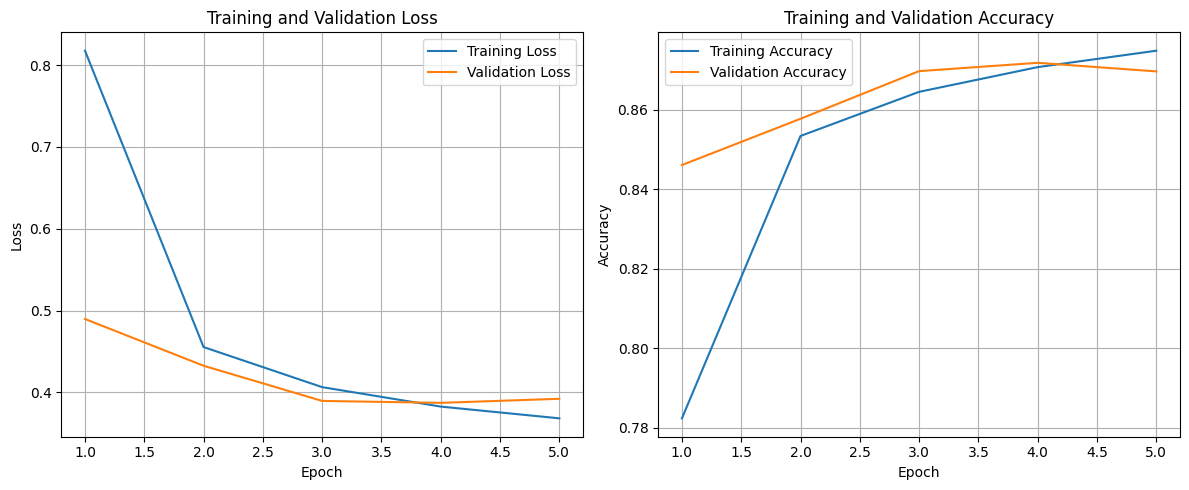

In [ ]:
# 8. Visualize Training History

# Plotting training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### 9. Evaluate Model on Test Set

Finally, let's evaluate the trained model on the test dataset to get an unbiased estimate of its performance.

In [ ]:
print("\nEvaluating model on the test set...")

model.eval()  # Set the model to evaluation mode
correct_test = 0
total_test = 0
test_loss = 0.0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

final_test_loss = test_loss / len(test_dataset)
final_test_accuracy = correct_test / total_test

print(f'Test Loss: {final_test_loss:.4f}')
print(f'Test Accuracy: {final_test_accuracy:.4f}')



Evaluating model on the test set...
Test Loss: 0.3839
Test Accuracy: 0.8734
